In [1]:
import json
import re
from pathlib import Path
import pandas as pd
from loguru import logger

In [2]:

REPO_ROOT = Path.cwd().resolve()
REPORTS_PATH = REPO_ROOT / "../analysis" / "results" / "data" / "reports.jsonl"
CSV_PATH = REPO_ROOT / "../analysis" / "results" / "data" / "overall_trace.csv"

In [3]:

def load_reports_data() -> pd.DataFrame:
    """Load main benchmark reports dataset."""
    if not REPORTS_PATH.exists():
        msg = f"Reports file not found: {REPORTS_PATH}"
        raise FileNotFoundError(msg)

    df = pd.read_json(REPORTS_PATH, lines=True)  # noqa: PD901
    logger.info(f"Loaded {len(df)} rows from reports.jsonl")
    return df


In [4]:
#data  = load_reports_data()

data = pd.read_csv(CSV_PATH)

In [5]:
group_cols = [
    "model",
    "environment",
    "level",
    "category",
    "verbosity",
    "task",
]

data["trial"] = data.groupby(group_cols).cumcount() + 1

item_cols = [
    "environment",
    "scaffold",
    "level",
    "category",
    "verbosity",
    "task",
]

data["item_id"] = (
    data[item_cols]
    .astype(str)
    .agg("|".join, axis=1)
)
data["respondent"] = (
    data["model"] + "_trial" + data["trial"].astype(str)
)

In [6]:
response_matrix = data.pivot(
    index="respondent",
    columns="item_id",
    values="success"
)

print(response_matrix.shape)

(40, 5406)


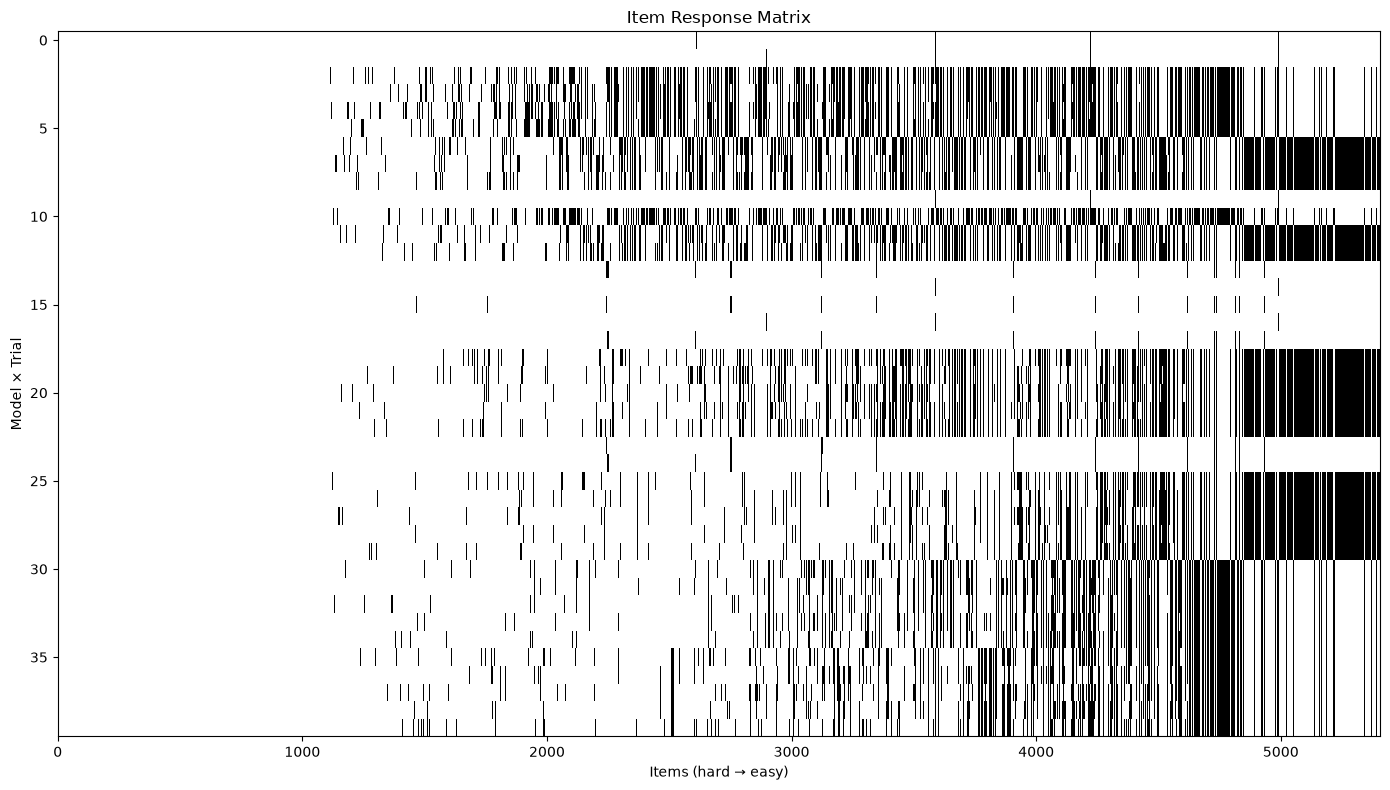

In [7]:
import numpy as np

# respondent ability proxy
row_mean = response_matrix.mean(axis=1)

# item easiness
col_mean = response_matrix.mean(axis=0)

response_matrix = response_matrix.loc[
    row_mean.sort_values(ascending=False).index,
    col_mean.sort_values().index
]

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plt.imshow(
    response_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys",
    vmin=0,
    vmax=1
)

plt.xlabel("Items (hard → easy)")
plt.ylabel("Model × Trial")
plt.title("Item Response Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# create and item response matrix. here each model agent comibnation could be one model in y axis and and on x we have tasks average score


In [ ]:
"""
The overall_trace.csv dataset contains trial-level evaluation results for an LLM benchmark.
Each row represents one trial of a single model–agent (scaffold) solving a single benchmark item. 
The benchmark includes 3 models, 2 agent scaffolds (react and tool_calling), 8 environments, 4 scopes (some has less number of scopes) , and 3 verbosity settings.

The category column distinguishes between whole tasks (task) and independently evaluated subtasks (subtask); there are approximately 95 unique tasks and 586 unique subtasks, each belonging to one of the environments. 

For nearly every unique (model, scaffold, environment, level, category, verbosity, task) combination, there are 5 repeated trials, with the binary success column indicating whether that trial succeeded. The score column is the numeric evaluation score, while pass@1–pass@5 and pass^1–pass^5 are derived aggregate metrics computed over the five trials and are repeated on every trial row—they are not independent observations. 



For psychometric analysis (e.g., IRT), the natural respondents are model × scaffold combinations, the items are tasks and/or subtasks, and the five repeated success values for each respondent–item pair should be treated as repeated Bernoulli observations rather than separate benchmark items.
"""

SyntaxError: incomplete input (604723599.py, line 1)